# Bengaluru Traffic Incident Pipeline

This notebook builds two models from the anonymised Astram incident dataset:

1. A classifier that predicts whether an incident requires a road closure.
2. A regressor that predicts an operational severity score from 0 to 10.

It then derives a barricade count, a manpower plan and a diversion strategy,
and exports every trained object so the dashboard can reuse it. Run the cells
in order.

## 1. Setup

In [1]:
import warnings
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, r2_score, classification_report,
    confusion_matrix, roc_auc_score,
)
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

# Closure is declared only when the classifier probability clears this value.
CLOSURE_DECISION_THRESHOLD = 0.65

## 2. Import the data

On Google Colab the cell opens an upload dialog and reads whatever file is
uploaded. Outside Colab it reads the same CSV from the working directory, so
the notebook runs unchanged in both places.

In [2]:
DATA_FILE = 'Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv'

try:
    from google.colab import files
    uploaded = files.upload()
    DATA_FILE = list(uploaded.keys())[0]
except Exception:
    pass

df_raw = pd.read_csv(DATA_FILE)
print('Source file :', DATA_FILE)
print('Rows, columns:', df_raw.shape)
df_raw.head()

Source file : Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv
Rows, columns: (8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,start_datetime,end_datetime,status,authenticated,modified_datetime,map_file,direction,description,veh_type,veh_no,corridor,priority,cargo_material,reason_breakdown,age_of_truck,created_date,route_path,client_id,created_by_id,last_modified_by_id,assigned_to_police_id,citizen_accident_id,comment,police_station,meta_data,kgid,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,2024-03-07 17:01:48.111+00,NaN,closed,yes,2024-03-07 19:35:47.871698+00,NaN,NaN,s m circle in coming man track,lcv,FKN00GL0000,Tumkur Road,High,NaN,NaN,NaN,2024-03-07 17:03:51.164032+00,NaN,1,FKUSR00000,FKUSR00001,NaN,NaN,NaN,Peenya,NaN,FKKG000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,2024-01-30 04:07:24.173+00,NaN,resolved,yes,2024-01-30 04:17:46.828979+00,NaN,NaN,Starting problem,heavy_vehicle,FKN00GL0001,ORR East 1,High,NaN,NaN,NaN,2024-01-30 04:08:22.954979+00,NaN,1,FKUSR00002,FKUSR00001,NaN,NaN,NaN,HSR Layout,NaN,FKKG000001,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,2023-11-11 06:18:03.343+00,NaN,closed,yes,2024-01-30 04:56:03.282003+00,NaN,NaN,ಊರ್ವಶಿ ಜಂಕ್ಷನ್ ನಲ್ಲಿ ಒಳಚರಂಡಿ ಚೇಂಬರ್ ಗೆ ಹೊಸದಾಗಿ...,NaN,NaN,Non-corridor,Low,NaN,NaN,NaN,2023-11-11 06:20:00.989398+00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,2024-03-07 17:56:55.061+00,NaN,closed,yes,2024-03-14 07:42:05.55005+00,NaN,NaN,tree fall,NaN,NaN,Non-corridor,Low,NaN,NaN,NaN,2024-03-07 17:58:56.696892+00,NaN,1,FKUSR00004,FKUSR00001,NaN,NaN,NaN,Sadashivanagar,NaN,FKKG000003,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,2024-01-30 04:56:32.348+00,NaN,closed,yes,2024-01-30 05:35:17.33908+00,NaN,NaN,[LOCATION] ಪೈಪ್ [PERSON] ವಾಹನ ಆಫ್ ಆಗಿರುತ್ತದೆ ಸರ್,private_bus,FKN00GL0002,Non-corridor,Low,NaN,NaN,NaN,2024-01-30 04:58:55.937662+00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


## 3. Scope the columns

Keep the fields the models use and, when present, drop unverified reports.

In [3]:
keep_cols = ['event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude',
             'address', 'event_cause', 'requires_road_closure', 'start_datetime',
             'end_datetime', 'veh_type', 'corridor',
             'priority', 'created_date', 'police_station', 'closed_datetime',
             'gba_identifier', 'zone', 'junction', 'authenticated']
df = df_raw[[c for c in keep_cols if c in df_raw.columns]].copy()

if 'authenticated' in df.columns:
    df = df[df['authenticated'].astype(str).str.strip().str.upper() != 'NO']

df = df.reset_index(drop=True)
print('Rows after scoping:', df.shape[0])

Rows after scoping: 7166


## 4. Exploratory data analysis

A quick look at class balance, missing values and the main categorical fields
before any transformation.

In [4]:
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head(12).to_string())

Missing values per column:
end_datetime       6710
junction           4974
closed_datetime    4754
zone               4147
gba_identifier     4147
veh_type           2929
endlatitude         164
endlongitude        164
corridor             17
address               2
priority              2
created_date          0


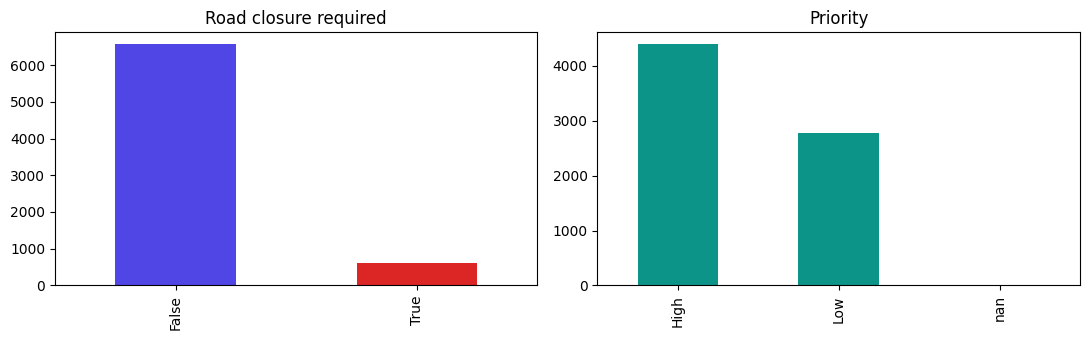

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

df['requires_road_closure'].astype(str).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4f46e5', '#dc2626'])
ax[0].set_title('Road closure required')
ax[0].set_xlabel('')

df['priority'].astype(str).value_counts().plot(
    kind='bar', ax=ax[1], color='#0d9488')
ax[1].set_title('Priority')
ax[1].set_xlabel('')

plt.tight_layout()
plt.show()

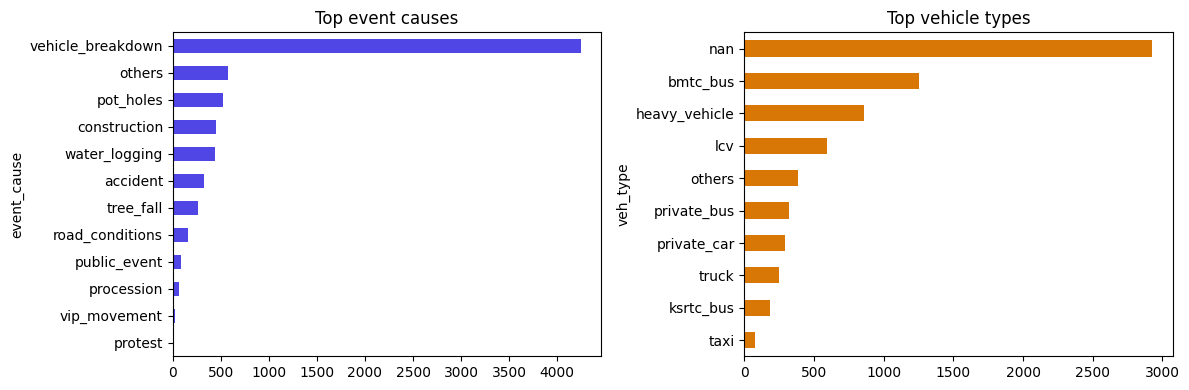

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['event_cause'].astype(str).str.strip().str.lower().value_counts().head(12).plot(
    kind='barh', ax=ax[0], color='#4f46e5')
ax[0].set_title('Top event causes')
ax[0].invert_yaxis()

df['veh_type'].astype(str).str.strip().str.lower().value_counts().head(10).plot(
    kind='barh', ax=ax[1], color='#d97706')
ax[1].set_title('Top vehicle types')
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

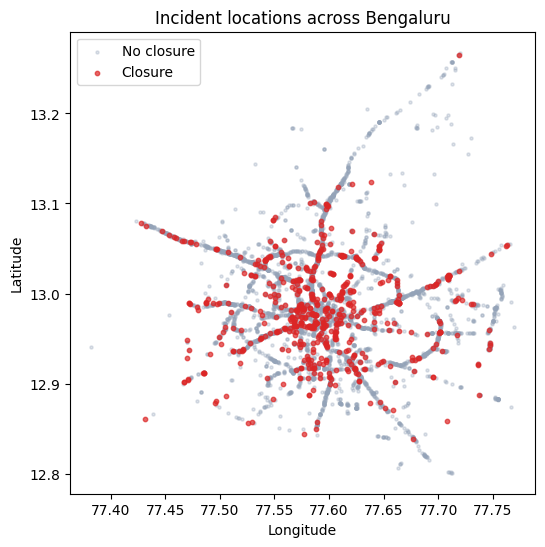

In [7]:
# Spatial spread of incidents, highlighting the ones that needed a closure.
plt.figure(figsize=(6, 6))
closed = df['requires_road_closure'].astype(str).str.lower().isin(['true', '1'])
plt.scatter(df.loc[~closed, 'longitude'], df.loc[~closed, 'latitude'],
            s=5, alpha=0.3, color='#94a3b8', label='No closure')
plt.scatter(df.loc[closed, 'longitude'], df.loc[closed, 'latitude'],
            s=10, alpha=0.7, color='#dc2626', label='Closure')
plt.title('Incident locations across Bengaluru')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend()
plt.show()

## 5. Cleaning and priority mapping

In [8]:
if 'gba_identifier' in df.columns:
    df.drop(columns=['gba_identifier'], inplace=True)

df['requires_road_closure'] = (
    df['requires_road_closure'].astype(str).str.strip().str.lower()
    .map({'true': 1, 'false': 0, '1': 1, '0': 0})
    .fillna(0).astype(int)
)

# The same key cleaning is applied to dashboard strings at prediction time, so
# the rate dictionaries built later are looked up with matching keys.
def clean_key(s):
    s = str(s).strip().lower()
    return re.sub(r'[\s\-]+', '_', s)

for col in ['event_cause', 'event_type', 'veh_type', 'corridor', 'zone', 'junction', 'police_station']:
    if col in df.columns:
        df[col] = df[col].apply(clean_key)
        df[col] = df[col].replace({'nan': np.nan, 'none': np.nan, '': np.nan})

if 'event_cause' in df.columns:
    df = df[~df['event_cause'].isin(['test', 'demo', 'test_demo'])].reset_index(drop=True)

PRIORITY_ORDINAL_MAP = {'low': 1, 'medium': 2, 'high': 3, 'critical': 4}
df['priority_num'] = (
    df['priority'].astype(str).str.strip().str.lower()
    .map(PRIORITY_ORDINAL_MAP).fillna(1).astype(int)
)
print('priority_num counts:', df['priority_num'].value_counts().sort_index().to_dict())

priority_num counts: {1: 2773, 3: 4393}


## 6. Temporal features

Hour and day are encoded as sine/cosine pairs. The raw hour is used to derive
rush-hour flags and is removed from the model matrix later.

In [9]:
for col in ['start_datetime', 'closed_datetime', 'created_date', 'end_datetime']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

df['hour_of_day'] = df['start_datetime'].dt.hour.fillna(12).astype(int)
df['day_of_week'] = df['start_datetime'].dt.dayofweek.fillna(0).astype(int)
df['month'] = df['start_datetime'].dt.month.fillna(6).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['is_night'] = df['hour_of_day'].apply(lambda h: 1 if (h >= 22 or h <= 5) else 0)
df['is_weekend'] = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0)
df['is_monsoon'] = df['month'].apply(lambda m: 1 if m in [6, 7, 8, 9] else 0)
df['is_unresolved'] = df['closed_datetime'].isnull().astype(int)

df['is_rush'] = ((df['hour_of_day'].between(7, 10)) | (df['hour_of_day'].between(17, 21))).astype(int)
df['hour_peak_prox'] = df['hour_of_day'].apply(lambda h: (9 - min(abs(h - 9), abs(h - 18))) / 9)

## 7. Vehicle type

Vehicle labels are mapped to a small set of canonical types. Missing values
are filled from time and event context rather than location.

In [10]:
VEH_MAP = {
    'two_wheeler': 'two_wheeler', 'bike': 'two_wheeler', 'motorcycle': 'two_wheeler',
    'three_wheeler': 'three_wheeler', 'auto': 'three_wheeler', 'autorickshaw': 'three_wheeler',
    'lcv': 'lcv', 'light_commercial': 'lcv',
    'hcv': 'hcv', 'heavy_commercial': 'hcv',
    'heavy_vehicle': 'heavy_vehicle', 'truck': 'truck',
    'bus': 'bus', 'bmtc': 'bmtc', 'bmtc_bus': 'bmtc', 'ksrtc': 'bus', 'ksrtc_bus': 'bus',
    'private_bus': 'bus', 'private_car': 'car',
    'car': 'car', 'suv': 'car', 'taxi': 'car', 'cab': 'car',
    'ambulance': 'ambulance',
}
df['veh_type'] = df['veh_type'].map(VEH_MAP).fillna(df['veh_type'])

veh_le = LabelEncoder()
veh_le.fit(list(df['veh_type'].dropna().unique()) + ['unknown'])
et_le = LabelEncoder().fit(df['event_type'].fillna('unknown'))
ec_le = LabelEncoder().fit(df['event_cause'].fillna('unknown'))

NON_GEO_IMPUTE_COLS = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
                       'requires_road_closure', 'event_type_enc', 'event_cause_enc']
df['event_type_enc'] = et_le.transform(df['event_type'].fillna('unknown'))
df['event_cause_enc'] = ec_le.transform(df['event_cause'].fillna('unknown'))

has_veh = df['veh_type'].notna()
if has_veh.sum() > 0:
    tmp = df[NON_GEO_IMPUTE_COLS].copy()
    tmp['veh_enc'] = np.nan
    tmp.loc[has_veh, 'veh_enc'] = veh_le.transform(df.loc[has_veh, 'veh_type'].fillna('unknown'))
    imputed = KNNImputer(n_neighbors=5).fit_transform(tmp)
    col_idx = tmp.columns.get_loc('veh_enc')
    df['veh_type'] = veh_le.inverse_transform(
        np.clip(np.round(imputed[:, col_idx]).astype(int), 0, len(veh_le.classes_) - 1)
    )

df['veh_type'] = df['veh_type'].fillna('unknown')
df.drop(columns=['event_type_enc', 'event_cause_enc'], inplace=True)

HEAVY_PATTERN = r'heavy|hcv|bus|bmtc|truck|ksrtc'
df['is_heavy_vehicle'] = df['veh_type'].str.contains(HEAVY_PATTERN, na=False).astype(int)
print('Heavy vehicle share:', round(df['is_heavy_vehicle'].mean(), 3))

Heavy vehicle share: 0.608


## 8. Highway flag from address

In [11]:
if 'address' in df.columns:
    HIGHWAY_PATTERN = r'\bnh\b|\bsh\b|\bnational highway\b|\bstate highway\b|flyover|elevated'
    df['is_highway'] = df['address'].astype(str).str.lower().str.contains(HIGHWAY_PATTERN, na=False).astype(int)
    df.drop(columns=['address'], inplace=True)
print('Highway share:', round(df['is_highway'].mean(), 3))

Highway share: 0.021


## 9. Distance to centre and incident span

Haversine distance from the city centre, and the physical length of the
incident. Single-point incidents (no end coordinates) get a zero span.

In [12]:
BLR_CENTER_LAT, BLR_CENTER_LON = 12.9716, 77.5946


def haversine_km(lat, lon, clat=BLR_CENTER_LAT, clon=BLR_CENTER_LON):
    R = 6371.0
    dlat = np.radians(lat - clat)
    dlon = np.radians(lon - clon)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(clat)) * np.cos(np.radians(lat)) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


df['dist_to_center_km'] = haversine_km(df['latitude'].values, df['longitude'].values)

end_missing = (
    df['endlatitude'].isna() | df['endlongitude'].isna() |
    (df['endlatitude'] == 0) | (df['endlongitude'] == 0)
)
df['incident_span_m'] = haversine_m(
    df['latitude'].values, df['longitude'].values,
    df['endlatitude'].fillna(df['latitude']).values,
    df['endlongitude'].fillna(df['longitude']).values,
)
df.loc[end_missing, 'incident_span_m'] = 0.0
df['incident_span_m'] = df['incident_span_m'].fillna(0.0)
print(f'Mean distance to centre: {df["dist_to_center_km"].mean():.2f} km')

Mean distance to centre: 8.19 km


## 10. Zone imputation

Zone is a spatial label, so missing zones are filled from coordinates.

In [13]:
zone_known = df['zone'].notna()
if zone_known.sum() > 100:
    zone_le = LabelEncoder().fit(df.loc[zone_known, 'zone'])
    tmp_z = df[['latitude', 'longitude']].copy()
    tmp_z['zone_enc'] = np.nan
    tmp_z.loc[zone_known, 'zone_enc'] = zone_le.transform(df.loc[zone_known, 'zone'])
    imputed_z = KNNImputer(n_neighbors=5).fit_transform(tmp_z)
    df['zone'] = zone_le.inverse_transform(
        np.clip(np.round(imputed_z[:, 2]).astype(int), 0, len(zone_le.classes_) - 1)
    )
else:
    df['zone'] = df['zone'].fillna('unknown')

## 11. Corridor flag and cause tier

In [14]:
NON_CORRIDOR = ['non-corridor', 'non_corridor', 'nan', 'none', '']
df['is_on_corridor'] = (~df['corridor'].isin(NON_CORRIDOR) & df['corridor'].notna()).astype(int)
df['corridor'] = df['corridor'].fillna('non_corridor')

# Relative severity weight per cause, used in the severity index and as a model feature.
CAUSE_TIER = {
    'vip_movement': 1.00, 'protest': 1.00, 'procession': 0.90, 'accident': 0.85,
    'waterlogging': 0.85, 'water_logging': 0.85, 'flood': 0.75, 'road_work': 0.80,
    'construction': 0.55, 'tree_fallen': 0.65, 'tree_fall': 0.65,
    'vehicle_breakdown': 0.45, 'breakdown': 0.45, 'encroachment': 0.30, 'pot_holes': 0.35,
    'fog_low_visibility': 0.25, 'power_outage': 0.20, 'congestion': 0.50,
    'road_conditions': 0.45, 'public_event': 0.70, 'debris': 0.40, 'others': 0.40, 'other': 0.40,
}
DEFAULT_TIER = 0.40
df['cause_tier'] = df['event_cause'].map(CAUSE_TIER).fillna(DEFAULT_TIER)

df['has_junction'] = df['junction'].notna().astype(int)
df['junction'] = df['junction'].fillna('no_junction')
df['police_station'] = df['police_station'].fillna('unknown')

## 12. Train and test split

The split happens before any aggregate statistic is computed. Every artifact
fit below (clustering, frequency tables, rate tables, scalers, PCA) uses the
training rows only and is then applied to the test rows and to live input.

In [15]:
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df['requires_road_closure']
)
df['is_train'] = False
df.loc[train_idx, 'is_train'] = True
train_mask = df['is_train'].values
print(f'Train rows: {train_mask.sum()}   Test rows: {(~train_mask).sum()}')

Train rows: 5732   Test rows: 1434


## 13. Spatial clustering and frequency tables (train only)

In [16]:
kmeans = MiniBatchKMeans(n_clusters=30, random_state=RANDOM_STATE, batch_size=1024)
kmeans.fit(df.loc[train_mask, ['latitude', 'longitude']].values)
df['location_cluster'] = kmeans.predict(df[['latitude', 'longitude']].values)

cluster_density = df.loc[train_mask].groupby('location_cluster').size().rename('cluster_event_density')
cluster_density_mean_train = cluster_density.mean()
df['cluster_event_density'] = df['location_cluster'].map(cluster_density).fillna(cluster_density_mean_train)

junc_freq = df.loc[train_mask, 'junction'].value_counts().to_dict()
df['junction_freq'] = df['junction'].map(junc_freq).fillna(1)

station_freq = df.loc[train_mask, 'police_station'].value_counts().to_dict()
df['station_event_freq'] = df['police_station'].map(station_freq).fillna(1)
print('Clustering and frequency tables built on training rows.')

Clustering and frequency tables built on training rows.


## 14. Priority-rate encodings (train only)

Each zone, corridor and cluster gets the average priority level of its
training incidents. Groups with too few rows fall back to the global mean.

In [17]:
MIN_COUNT = 10


def priority_rate(frame, col, fallback):
    grp = frame.groupby(col)['priority_num'].agg(['mean', 'count'])
    grp.columns = ['rate', 'cnt']
    grp['rate_smooth'] = np.where(grp['cnt'] >= MIN_COUNT, grp['rate'], fallback)
    return grp['rate_smooth'].to_dict()


train_df = df.loc[train_mask]
global_mean = train_df['priority_num'].mean()

zone_rate_dict = priority_rate(train_df, 'zone', global_mean)
corridor_rate_dict = priority_rate(train_df, 'corridor', global_mean)
cluster_rate_dict = priority_rate(train_df, 'location_cluster', global_mean)

df['zone_priority_rate'] = df['zone'].map(zone_rate_dict).fillna(global_mean)
df['corridor_priority_rate'] = df['corridor'].map(corridor_rate_dict).fillna(global_mean)
df['cluster_priority_rate'] = df['location_cluster'].map(cluster_rate_dict).fillna(global_mean)
print(f'Global priority rate: {global_mean:.3f}')

Global priority rate: 2.233


## 15. Interactions and one-hot encoding

The raw hour is dropped after its cyclic version exists. One-hot categories
are learned from the training rows only.

In [18]:
df['rush_x_corridor'] = df['is_rush'] * df['is_on_corridor']

# During training this uses the historical closure label. At prediction time it
# is recomputed from the classifier's predicted closure.
df['heavy_x_closure'] = df['is_heavy_vehicle'] * df['requires_road_closure']

OHE_COLS = ['event_cause', 'event_type', 'veh_type', 'zone']
ohe_categories = {c: sorted(df.loc[train_mask, c].dropna().unique().tolist()) for c in OHE_COLS}
for c in OHE_COLS:
    df[c] = pd.Categorical(df[c], categories=ohe_categories[c])

df_encoded = pd.get_dummies(df, columns=OHE_COLS, prefix=OHE_COLS, drop_first=False, dtype=int)

DROP_COLS = ['end_datetime', 'closed_datetime', 'created_date', 'start_datetime',
             'priority', 'corridor', 'junction', 'police_station', 'authenticated']
df_encoded.drop(columns=[c for c in DROP_COLS if c in df_encoded.columns], inplace=True)
print('Encoded shape:', df_encoded.shape)

Encoded shape: (7166, 69)


## 16. Feature normalisation (scalers fit on train only)

In [19]:
train_mask_enc = df_encoded['is_train'].values

jf_scaler = MinMaxScaler().fit(df_encoded.loc[train_mask_enc, ['junction_freq']])
df_encoded['junction_freq_norm'] = jf_scaler.transform(df_encoded[['junction_freq']])

cd_scaler = MinMaxScaler().fit(df_encoded.loc[train_mask_enc, ['cluster_event_density']])
df_encoded['cluster_density_norm'] = cd_scaler.transform(df_encoded[['cluster_event_density']])

# Drop the raw versions so the same signal is not represented twice.
df_encoded.drop(columns=['junction_freq', 'cluster_event_density', 'hour_of_day'], inplace=True)
print('Normalised junction frequency and cluster density.')

Normalised junction frequency and cluster density.


## 17. Severity target

A one-component PCA over the disruption inputs sets data-driven weights; the
blended score is scaled to 0-10. All three fitted objects use training rows only.

Severity weights: {'cause_tier': np.float64(0.211), 'requires_road_closure': np.float64(0.119), 'is_on_corridor': np.float64(0.193), 'is_heavy_vehicle': np.float64(0.024), 'hour_peak_prox': np.float64(0.079), 'junction_freq_norm': np.float64(0.231), 'cluster_density_norm': np.float64(0.143)}


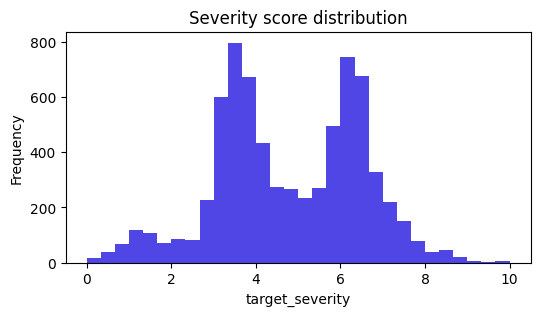

In [20]:
SEVERITY_PCA_COLS = [
    'cause_tier', 'requires_road_closure', 'is_on_corridor', 'is_heavy_vehicle',
    'hour_peak_prox', 'junction_freq_norm', 'cluster_density_norm'
]

sev_feature_scaler = StandardScaler()
X_sev_scaled = sev_feature_scaler.fit_transform(df_encoded.loc[train_mask_enc, SEVERITY_PCA_COLS])

pca = PCA(n_components=1, random_state=RANDOM_STATE).fit(X_sev_scaled)
weights = np.abs(pca.components_[0])
weights = weights / weights.sum()
SEVERITY_WEIGHTS = dict(zip(SEVERITY_PCA_COLS, weights))

raw_sev = np.zeros(len(df_encoded))
for feat, w in SEVERITY_WEIGHTS.items():
    raw_sev += df_encoded[feat].fillna(0) * w
raw_sev = pd.Series(raw_sev)

sev_scaler = MinMaxScaler(feature_range=(0, 10)).fit(raw_sev[train_mask_enc].values.reshape(-1, 1))
df_encoded['target_severity'] = sev_scaler.transform(raw_sev.values.reshape(-1, 1)).flatten().clip(0, 10)

print('Severity weights:', {k: round(v, 3) for k, v in SEVERITY_WEIGHTS.items()})
plt.figure(figsize=(6, 3))
df_encoded['target_severity'].plot(kind='hist', bins=30, color='#4f46e5')
plt.title('Severity score distribution'); plt.xlabel('target_severity')
plt.show()

## 18. Barricade target

Severity, closure confidence and incident span are combined with
multiplicative curves. The closure term is zero below the decision threshold
and ramps up above it.

In [21]:
BARRICADE_BASE = 3.0
BARRICADE_FLOOR = 2
BARRICADE_CEILING = 50
GRAVITY_K_SEVERITY = 2.2
GRAVITY_P_SEVERITY = 1.6
GRAVITY_K_CLOSURE = 1.3
GRAVITY_K_SPAN = 1.1
GRAVITY_P_SPAN = 0.65
SPAN_SCALE_M = 60.0
CORRIDOR_GRAVITY_BONUS = 0.35


def calculate_barricades(severity, closure_proba, incident_span_m, is_on_corridor):
    severity = float(np.clip(severity, 0, 10))
    closure_proba = float(np.clip(closure_proba, 0, 1))
    incident_span_m = max(0.0, float(incident_span_m))

    closure_gravity = 0.0
    if closure_proba >= CLOSURE_DECISION_THRESHOLD:
        closure_gravity = (closure_proba - CLOSURE_DECISION_THRESHOLD) / (1 - CLOSURE_DECISION_THRESHOLD)

    severity_term = 1 + GRAVITY_K_SEVERITY * (severity / 10) ** GRAVITY_P_SEVERITY
    closure_term = 1 + GRAVITY_K_CLOSURE * closure_gravity
    span_term = 1 + GRAVITY_K_SPAN * (incident_span_m / SPAN_SCALE_M) ** GRAVITY_P_SPAN
    corridor_term = (1 + CORRIDOR_GRAVITY_BONUS) if is_on_corridor else 1.0

    raw = BARRICADE_BASE * severity_term * closure_term * span_term * corridor_term
    return int(np.clip(round(raw), BARRICADE_FLOOR, BARRICADE_CEILING))


df_encoded['target_barricades'] = [
    calculate_barricades(s, float(c), span, corr)
    for s, c, span, corr in zip(
        df_encoded['target_severity'], df_encoded['requires_road_closure'],
        df_encoded['incident_span_m'], df_encoded['is_on_corridor'])
]
print(df_encoded['target_barricades'].describe().round(2).to_dict())

{'count': 7166.0, 'mean': 8.09, 'std': 7.37, 'min': 3.0, '25%': 5.0, '50%': 6.0, '75%': 8.0, 'max': 50.0}


## 19. Final feature matrix

Raw end coordinates are excluded because they are recorded only for closure
incidents and would leak the label. The targets and bookkeeping columns are
also excluded.

In [22]:
LEAKAGE_COLS = ['target_severity', 'target_barricades', 'is_train', 'endlatitude', 'endlongitude']
EXCLUDE_COLS = LEAKAGE_COLS + ['priority_num']
FINAL_FEATURES = [c for c in df_encoded.select_dtypes(include=[np.number]).columns
                  if c not in EXCLUDE_COLS]

X = df_encoded[FINAL_FEATURES].fillna(0)
y_severity = df_encoded['target_severity']

X_train, X_test = X.loc[train_mask_enc], X.loc[~train_mask_enc]
y_train_s, y_test_s = y_severity.loc[train_mask_enc], y_severity.loc[~train_mask_enc]
print(f'Features: {len(FINAL_FEATURES)}   X_train: {X_train.shape}   X_test: {X_test.shape}')

Features: 64   X_train: (5732, 64)   X_test: (1434, 64)


## 20. Model 1: closure classifier

Trained first so its prediction is available before the severity model's
interaction terms are built at prediction time.

In [23]:
CLOSURE_FEATURES = [c for c in FINAL_FEATURES if c not in ['requires_road_closure', 'heavy_x_closure']]

X_closure = df_encoded[CLOSURE_FEATURES].fillna(0)
y_closure = df_encoded['requires_road_closure']
Xc_train, Xc_test = X_closure.loc[train_mask_enc], X_closure.loc[~train_mask_enc]
yc_train, yc_test = y_closure.loc[train_mask_enc], y_closure.loc[~train_mask_enc]

closure_clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE)
closure_clf.fit(Xc_train, yc_train)

yc_pred = closure_clf.predict(Xc_test)
yc_proba = closure_clf.predict_proba(Xc_test)[:, 1]
print(classification_report(yc_test, yc_pred, target_names=['NO_CLOSURE', 'CLOSURE']))
print('ROC-AUC:', round(roc_auc_score(yc_test, yc_proba), 4))
print('Confusion matrix:')
print(confusion_matrix(yc_test, yc_pred))

              precision    recall  f1-score   support

  NO_CLOSURE       1.00      1.00      1.00      1314
     CLOSURE       0.97      0.95      0.96       120

    accuracy                           0.99      1434
   macro avg       0.98      0.97      0.98      1434
weighted avg       0.99      0.99      0.99      1434

ROC-AUC: 0.989
Confusion matrix:
[[1310    4]
 [   6  114]]


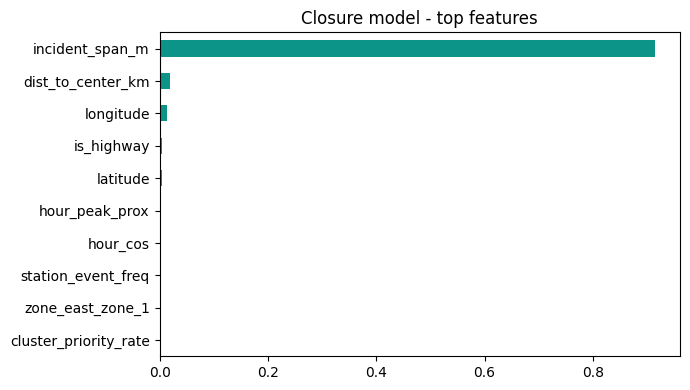

In [24]:
imp_c = pd.Series(closure_clf.feature_importances_, index=Xc_train.columns).sort_values()
imp_c.tail(10).plot(kind='barh', figsize=(7, 4), color='#0d9488')
plt.title('Closure model - top features'); plt.tight_layout(); plt.show()

## 21. Model 2: severity regressor

In [25]:
gbm = GradientBoostingRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE)
gbm.fit(X_train, y_train_s)

sev_pred = gbm.predict(X_test)
print('R2 :', round(r2_score(y_test_s, sev_pred), 4))
print('MAE:', round(mean_absolute_error(y_test_s, sev_pred), 4))
print(f'Predicted range: [{sev_pred.min():.2f}, {sev_pred.max():.2f}]  std={sev_pred.std():.2f}')

R2 : 0.9987
MAE: 0.0312
Predicted range: [0.01, 9.02]  std=1.74


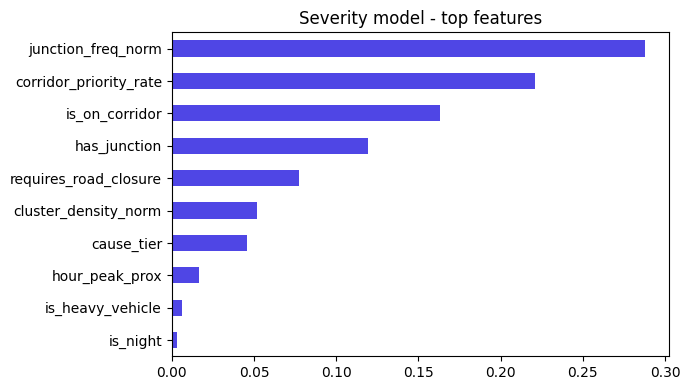

In [26]:
imp_s = pd.Series(gbm.feature_importances_, index=X_train.columns).sort_values()
imp_s.tail(10).plot(kind='barh', figsize=(7, 4), color='#4f46e5')
plt.title('Severity model - top features'); plt.tight_layout(); plt.show()

## 22. Prediction function

Rebuilds one feature row from raw inputs, runs the closure classifier, feeds
its result into the severity regressor, then computes barricades, manpower
and a diversion plan.

In [27]:
def _lookup_rate(rate_dict, raw_value, fallback):
    if raw_value is None:
        return fallback
    return rate_dict.get(clean_key(raw_value), fallback)


def build_feature_vector(cause, hour, day_of_week, latitude, longitude,
                         endlatitude, endlongitude, is_on_corridor,
                         zone_name, corridor_name, veh_type=None):
    is_on_corridor = int(bool(is_on_corridor))
    hour = int(hour) % 24
    day_of_week = int(day_of_week) % 7

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin = np.sin(2 * np.pi * day_of_week / 7)
    dow_cos = np.cos(2 * np.pi * day_of_week / 7)
    is_night = 1 if (hour >= 22 or hour <= 5) else 0
    is_weekend = 1 if day_of_week >= 5 else 0
    is_rush = 1 if (7 <= hour <= 10 or 17 <= hour <= 21) else 0
    hour_peak_prox = (9 - min(abs(hour - 9), abs(hour - 18))) / 9

    dist_to_center_km = float(haversine_km(np.array([latitude]), np.array([longitude]))[0])
    location_cluster = int(kmeans.predict([[latitude, longitude]])[0])
    cluster_density_val = float(cluster_density.get(location_cluster, cluster_density_mean_train))
    cluster_density_norm = float(cd_scaler.transform([[cluster_density_val]])[0, 0])
    cluster_priority_rate_val = cluster_rate_dict.get(location_cluster, global_mean)

    cause_norm = clean_key(cause)
    cause_tier_val = CAUSE_TIER.get(cause_norm, DEFAULT_TIER)

    veh_norm = clean_key(veh_type) if veh_type is not None else 'unknown'
    veh_mapped = VEH_MAP.get(veh_norm, veh_norm)
    is_heavy_vehicle = int(bool(re.search(HEAVY_PATTERN, veh_mapped)))

    zone_rate_val = _lookup_rate(zone_rate_dict, zone_name, global_mean)
    corridor_rate_val = (_lookup_rate(corridor_rate_dict, corridor_name, global_mean)
                         if is_on_corridor else corridor_rate_dict.get('non_corridor', global_mean))

    if endlatitude is None or endlongitude is None or endlatitude == 0 or endlongitude == 0:
        incident_span_m = 0.0
    else:
        incident_span_m = float(haversine_m(latitude, longitude, endlatitude, endlongitude))
        if np.isnan(incident_span_m):
            incident_span_m = 0.0

    junction_freq_norm_default = float(jf_scaler.transform([[1]])[0, 0])

    values = {
        'latitude': latitude, 'longitude': longitude, 'incident_span_m': incident_span_m,
        'day_of_week': day_of_week, 'month': 6,
        'hour_sin': hour_sin, 'hour_cos': hour_cos, 'dow_sin': dow_sin, 'dow_cos': dow_cos,
        'is_night': is_night, 'is_weekend': is_weekend, 'is_monsoon': 0,
        'is_unresolved': 1, 'is_heavy_vehicle': is_heavy_vehicle, 'is_highway': 0,
        'dist_to_center_km': dist_to_center_km, 'is_on_corridor': is_on_corridor,
        'location_cluster': location_cluster,
        'has_junction': 0, 'junction_freq_norm': junction_freq_norm_default, 'station_event_freq': 1,
        'cause_tier': cause_tier_val,
        'zone_priority_rate': zone_rate_val, 'corridor_priority_rate': corridor_rate_val,
        'cluster_priority_rate': cluster_priority_rate_val,
        'rush_x_corridor': is_rush * is_on_corridor, 'is_rush': is_rush,
        'hour_peak_prox': hour_peak_prox, 'cluster_density_norm': cluster_density_norm,
    }

    row = pd.DataFrame(0, index=[0], columns=CLOSURE_FEATURES, dtype=float)
    for k, v in values.items():
        if k in row.columns:
            row[k] = v
    for col, flag in [('event_cause_' + cause_norm, 1),
                      ('event_type_unplanned', 1),
                      ('zone_' + clean_key(zone_name) if zone_name else None, 1),
                      ('veh_type_' + veh_mapped, 1)]:
        if col and col in row.columns:
            row[col] = flag
    return row, location_cluster, dist_to_center_km, incident_span_m, is_heavy_vehicle


def recommend_manpower(severity, cause_tier):
    total = max(2, int(round(2 * np.exp(severity * 0.32))))
    if severity >= 7.5 or cause_tier >= 0.9:
        ins = max(1, int(total * 0.1)); hc = max(2, int(total * 0.3)); pc = total - (ins + hc)
        text = f'{total} Units ({ins} Inspector, {hc} HC, {pc} PC) [SECTOR COMMAND]'
    elif severity >= 4.5:
        hc = max(1, int(total * 0.25)); pc = total - hc
        text = f'{total} Units ({hc} Head Constable, {pc} PC)'
    else:
        text = f'{total} Police Constables (Routine Lane Management)'
    return {'total': total, 'display_text': text}


def recommend_diversion(severity, barricades, is_on_corridor):
    if barricades >= 25 and is_on_corridor:
        return 'Fully close the primary corridor segment. Reroute inbound traffic to parallel ring arterials.'
    if severity >= 5.5:
        return 'Enforce multi-point perimeter filtering. Restrict heavy transit vehicles at preceding junctions.'
    if barricades > 10:
        return 'Deploy single-lane bottlenecks. No macro route alterations required.'
    return 'Maintain standard stream. Handle locally with directional flag points.'


def get_deployment_plan(cause, hour, day_of_week, latitude, longitude,
                        endlatitude, endlongitude, is_on_corridor,
                        zone_name, corridor_name, veh_type=None, event_type='unplanned', verbose=True):
    row, cluster_id, dist_km, span_m, is_heavy = build_feature_vector(
        cause, hour, day_of_week, latitude, longitude,
        endlatitude, endlongitude, is_on_corridor, zone_name, corridor_name, veh_type)

    et_col = 'event_type_' + clean_key(event_type)
    if et_col in row.columns:
        row['event_type_unplanned'] = 0
        row[et_col] = 1

    closure_proba = float(closure_clf.predict_proba(row)[0, 1])
    closure_pred = int(closure_proba >= CLOSURE_DECISION_THRESHOLD)

    sev_row = row.reindex(columns=X_train.columns, fill_value=0)
    sev_row.loc[0, 'requires_road_closure'] = closure_pred
    if 'heavy_x_closure' in sev_row.columns:
        sev_row.loc[0, 'heavy_x_closure'] = is_heavy * closure_pred

    severity = float(np.clip(gbm.predict(sev_row)[0], 0, 10))
    barricades = calculate_barricades(severity, closure_proba, span_m, bool(is_on_corridor))
    cause_tier_val = CAUSE_TIER.get(clean_key(cause), DEFAULT_TIER)
    manpower = recommend_manpower(severity, cause_tier_val)
    diversion = recommend_diversion(severity, barricades, is_on_corridor)

    if verbose:
        print(f'{str(cause).upper()}  closure={"YES" if closure_pred else "NO"} '
              f'(p={closure_proba:.2f})  severity={severity:.2f}  barricades={barricades}')

    return {
        'closure_required': bool(closure_pred), 'closure_probability': closure_proba,
        'severity': severity, 'incident_span_m': span_m, 'is_heavy_vehicle': bool(is_heavy),
        'barricades': barricades, 'manpower_count': manpower['total'],
        'manpower_deployment': manpower['display_text'], 'diversion_plan': diversion,
    }


print('Prediction function ready.')

Prediction function ready.


## 23. Validation on held-out incidents

Real rows from the test split are passed through the prediction function and
the predicted closure is compared with the recorded label. No values are
hard-coded here; everything comes from the dataset.

In [28]:
sample = df.loc[~df['is_train']].sample(8, random_state=RANDOM_STATE)
correct = 0
for _, r in sample.iterrows():
    plan = get_deployment_plan(
        cause=str(r['event_cause']), hour=int(r['hour_of_day']), day_of_week=int(r['day_of_week']),
        latitude=r['latitude'], longitude=r['longitude'],
        endlatitude=r['endlatitude'], endlongitude=r['endlongitude'],
        is_on_corridor=int(r['is_on_corridor']), zone_name=str(r['zone']),
        corridor_name=str(r['corridor']), veh_type=str(r['veh_type']),
        event_type=str(r['event_type']), verbose=False)
    actual = int(r['requires_road_closure'])
    correct += int(plan['closure_required'] == bool(actual))
    print(f"{str(r['event_cause']):<20} predicted closure={plan['closure_required']!s:<5} "
          f"actual={bool(actual)!s:<5} severity={plan['severity']:.2f} barricades={plan['barricades']}")
print(f'\nClosure match on sample: {correct}/{len(sample)}')

others               predicted closure=False actual=False severity=4.06 barricades=6
others               predicted closure=False actual=False severity=1.79 barricades=3
vehicle_breakdown    predicted closure=False actual=False severity=4.25 barricades=6
vehicle_breakdown    predicted closure=False actual=False severity=2.30 barricades=4
vehicle_breakdown    predicted closure=False actual=False severity=3.52 barricades=4
vehicle_breakdown    predicted closure=False actual=False severity=2.02 barricades=4
vehicle_breakdown    predicted closure=False actual=False severity=3.54 barricades=6
water_logging        predicted closure=False actual=False severity=3.48 barricades=4

Closure match on sample: 8/8


## 24. Export the trained pipeline

Every object needed at prediction time is saved to the models folder, so the
dashboard rebuilds the exact same features and uses the exact same models.

In [29]:
os.makedirs('models', exist_ok=True)

joblib.dump(closure_clf, 'models/closure_classifier.joblib')
joblib.dump(gbm, 'models/severity_regressor.joblib')
joblib.dump(CLOSURE_FEATURES, 'models/closure_features.joblib')
joblib.dump(list(X_train.columns), 'models/severity_features.joblib')

joblib.dump({
    'zone_rate_dict': zone_rate_dict,
    'corridor_rate_dict': corridor_rate_dict,
    'cluster_rate_dict': cluster_rate_dict,
    'global_mean': global_mean,
    'kmeans': kmeans,
    'cluster_density': cluster_density.to_dict(),
    'cluster_density_mean_train': cluster_density_mean_train,
    'jf_scaler': jf_scaler,
    'cd_scaler': cd_scaler,
    'CAUSE_TIER': CAUSE_TIER,
    'DEFAULT_TIER': DEFAULT_TIER,
    'VEH_MAP': VEH_MAP,
    'HEAVY_PATTERN': HEAVY_PATTERN,
    'CLOSURE_DECISION_THRESHOLD': CLOSURE_DECISION_THRESHOLD,
    'barricade_params': {
        'BARRICADE_BASE': BARRICADE_BASE, 'BARRICADE_FLOOR': BARRICADE_FLOOR,
        'BARRICADE_CEILING': BARRICADE_CEILING, 'GRAVITY_K_SEVERITY': GRAVITY_K_SEVERITY,
        'GRAVITY_P_SEVERITY': GRAVITY_P_SEVERITY, 'GRAVITY_K_CLOSURE': GRAVITY_K_CLOSURE,
        'GRAVITY_K_SPAN': GRAVITY_K_SPAN, 'GRAVITY_P_SPAN': GRAVITY_P_SPAN,
        'SPAN_SCALE_M': SPAN_SCALE_M, 'CORRIDOR_GRAVITY_BONUS': CORRIDOR_GRAVITY_BONUS,
    },
}, 'models/runtime_lookups.joblib')

print('Saved models and runtime lookups to the models folder.')

Saved models and runtime lookups to the models folder.
